# Estimate the effects of amino acid substitutions on fitness
$$
\frac{1}{n}\left( \Delta s - W a \right)^\top C^{-1} \left( \Delta s - W a \right) + \lambda \lVert a \rVert_1
$$

$a$ describes the impact on fitness of specific amino acid substitutions. $W$ is the assignment of amino acid substitutions of pango lineages compared to their parent lineage, $C$ the diagonal covariance matrix between growth rate differences and $\Delta s$ the difference in growth rate between a pango lineage and its parent.

In [1]:
import pandas as pd
import numpy as np

import cvxpy as cp
from scipy.linalg import cholesky

from matplotlib import pyplot as plt
import seaborn as sns

from viral_variant_comp.aa_subst_impact import simulate_aa_substitution_data, estimate_aa_impact, calculate_root_mse, calculate_mae
from viral_variant_comp.aa_subst_impact import create_substitutions_df, create_pango_lineage_information_df, calculate_fitness_advantage_covariance, calculate_impact_estimates, bootstrap_aa_impact_estimates, calculate_impact_estimates_timesplit
from viral_variant_comp.plotting import plot_true_vs_est, plot_bootstrap_aa_impact, plot_bootstrap_aa_impact_violin, plot_loss_different_lambda, plot_aa_impac_distr_lambdas, plot_aa_impact_dist_cov, plot_aa_impact_time

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Start with Toy Problem


In [2]:
n_variants = 20
n_aachanges = 10

data = simulate_aa_substitution_data(n_variants, n_aachanges, noise_level=0)
data.keys()


dict_keys(['true_a', 'W', 'delta_s', 'C'])

## Solve quadratic programming problem

- cp.Minimize: minimize objective function
- cp.sum_squares(...): $\|... \|_2^2$
- OSQP: Operator Splitting Quadratic Program solver
    - uses ADMM-based algorithm (Alternating Direction Method of Multipliers)

In [3]:
# check whether matrix W is full rank
np.linalg.matrix_rank(data['W'])

np.int64(10)

Status: optimal
Optimal value of objective function: 2.0377015981751443e-15


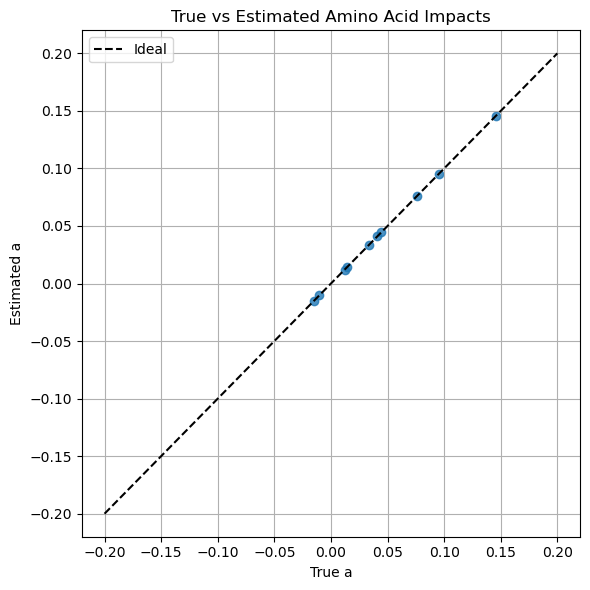

In [4]:
data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=1, noise_level=0)
est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=0)['a_est']
plot_true_vs_est(data['true_a'], est_a)


Status: optimal
Optimal value of objective function: 0.06092706323303443
Status: optimal
Optimal value of objective function: 0.06399820397442413
Status: optimal
Optimal value of objective function: 0.08933023053386194
Status: optimal
Optimal value of objective function: 0.18225663609313542
Status: optimal
Optimal value of objective function: 0.5676618875169329
Status: optimal
Optimal value of objective function: 0.03227674278832752
Status: optimal
Optimal value of objective function: 0.03477139745703966
Status: optimal
Optimal value of objective function: 0.05234681005595521
Status: optimal
Optimal value of objective function: 0.15190535526928065
Status: optimal
Optimal value of objective function: 0.6943262925097041
Status: optimal
Optimal value of objective function: 0.053369963265633286
Status: optimal
Optimal value of objective function: 0.07428332994662168
Status: optimal
Optimal value of objective function: 0.10283549590397692
Status: optimal
Optimal value of objective function:

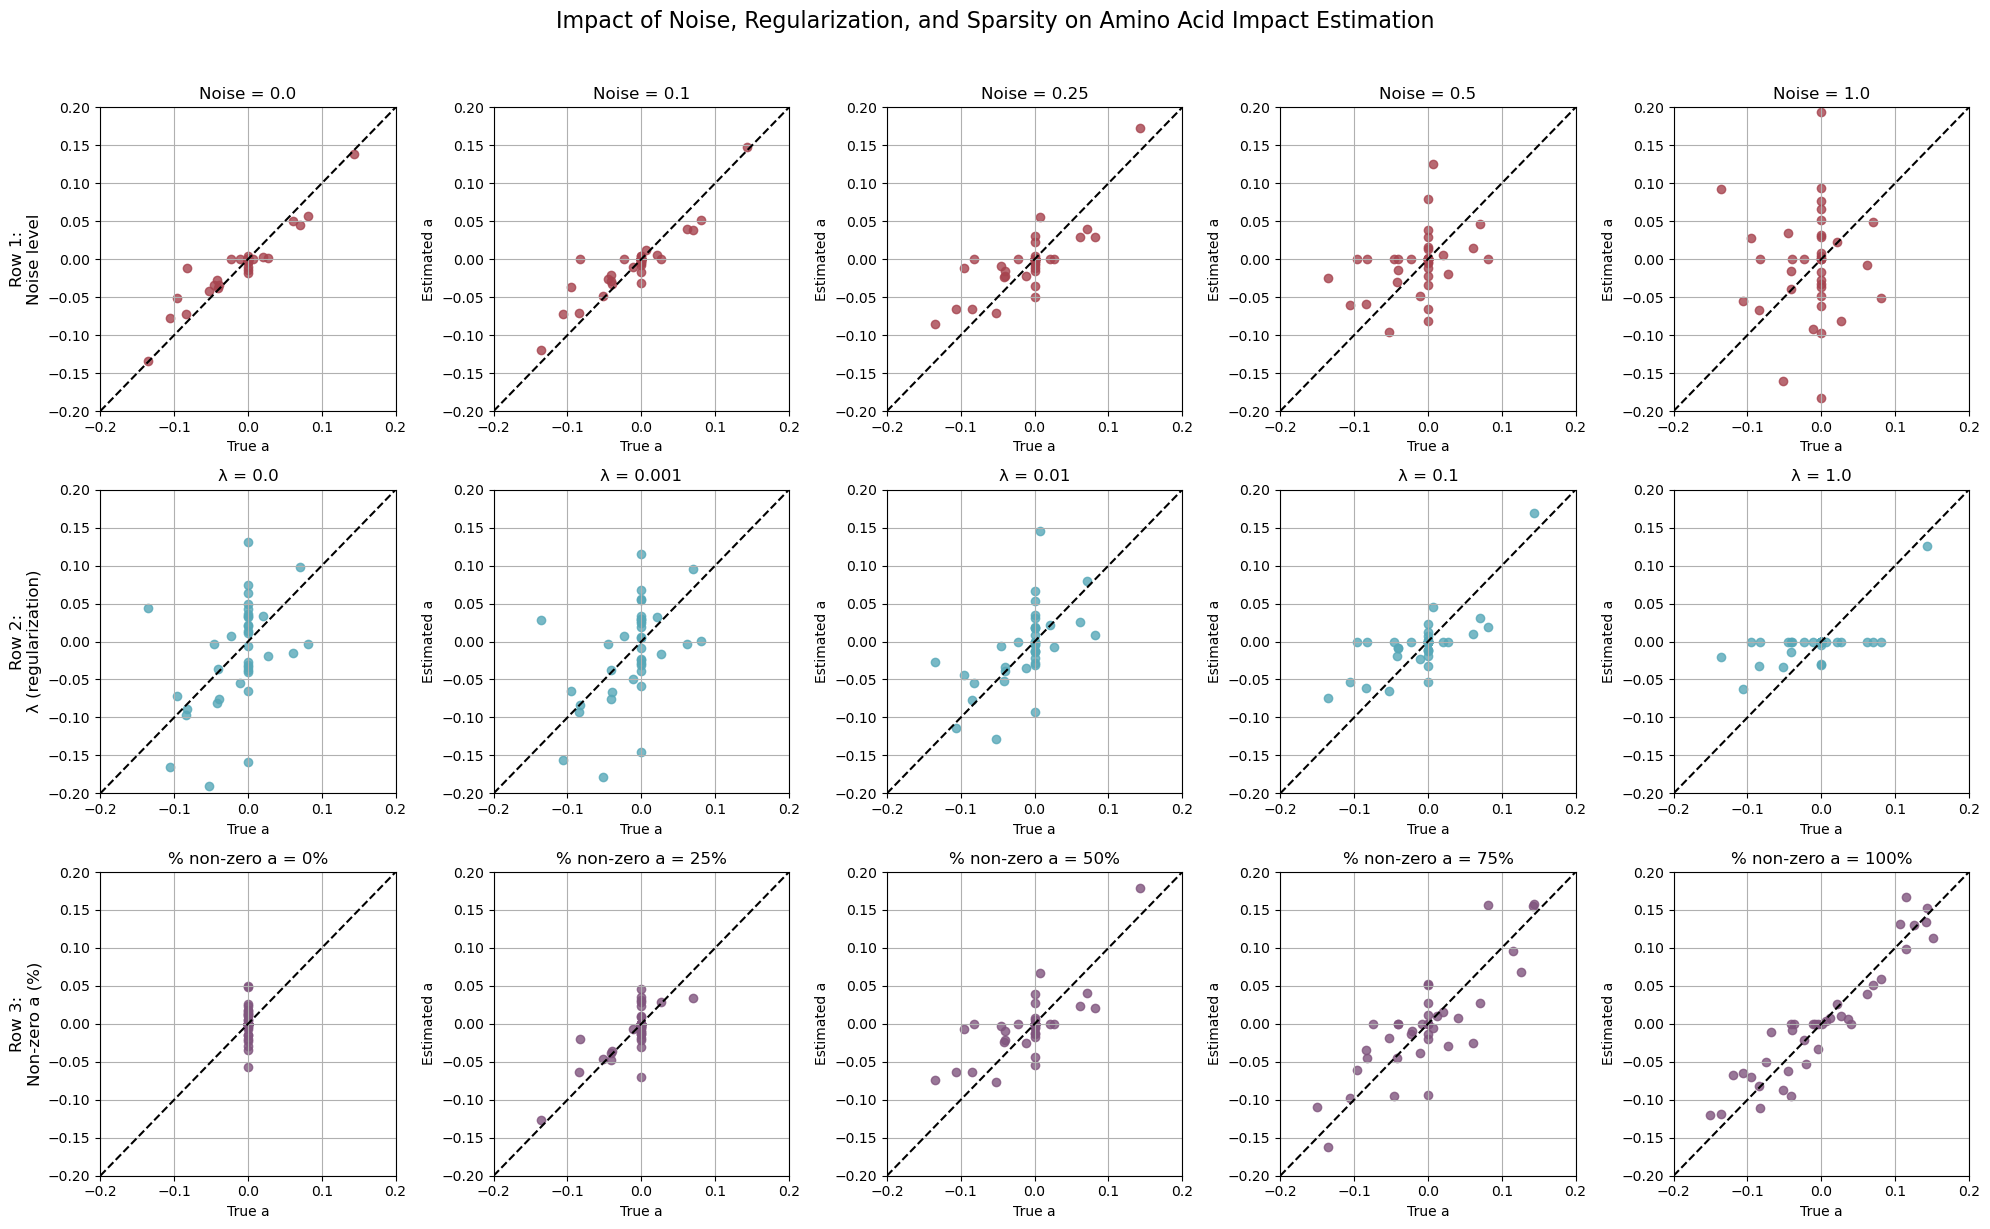

In [5]:
def plot_true_vs_est_subplot(ax, true_a, est_a, title="", color="blue"):
    ax.scatter(true_a, est_a, alpha=0.8, color=color)
    ax.plot([-0.2, 0.2], [-0.2, 0.2], 'k--', label='Ideal')
    ax.set_xlim(-0.2, 0.2)
    ax.set_ylim(-0.2, 0.2)
    ax.set_xlabel("True a")
    ax.set_ylabel("Estimated a")
    ax.set_title(title)
    ax.grid(True)

# --- Plot configuration ---
n_variants = 50
n_aachanges = 40
noise_levels = [0.0, 0.1, 0.25, 0.5, 1.0]
lambda_values = [0.0, 0.001, 0.01, 0.1, 1.0]
sparsity_levels = [0.0, 0.25, 0.5, 0.75, 1.0]
lambda_fixed = 0.05
noise_fixed = 0.3
percent_non0impact_aa_fixed = 0.5

# --- Subplots: 3 rows, 5 columns ---
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Row 1: Different noise levels
for i, noise in enumerate(noise_levels):
    data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=percent_non0impact_aa_fixed, noise_level=noise)
    est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=lambda_fixed)['a_est']
    plot_true_vs_est_subplot(axes[0, i], data['true_a'], est_a, title=f"Noise = {noise}", color="#a6444f")

# Row 2: Different lambda values
for i, _lambda in enumerate(lambda_values):
    data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=percent_non0impact_aa_fixed, noise_level=noise_fixed)
    est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=_lambda)['a_est']
    plot_true_vs_est_subplot(axes[1, i], data['true_a'], est_a, title=f"λ = {_lambda}", color = "#57a8b8")

# Row 3: Different sparsity levels (λ = 5)
for i, sparsity in enumerate(sparsity_levels):
    data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa=sparsity, noise_level=noise_fixed)
    est_a = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=lambda_fixed)['a_est']
    plot_true_vs_est_subplot(axes[2, i], data['true_a'], est_a, title=f"% non-zero a = {int(100 * sparsity)}%", color="#80557e")

# Row labels
axes[0, 0].set_ylabel("Row 1:\nNoise level", fontsize=12)
axes[1, 0].set_ylabel("Row 2:\nλ (regularization)", fontsize=12)
axes[2, 0].set_ylabel("Row 3:\nNon-zero a (%)", fontsize=12)

fig.suptitle("Impact of Noise, Regularization, and Sparsity on Amino Acid Impact Estimation", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


Status: optimal
Optimal value of objective function: 0.11071948087673775
Status: optimal
Optimal value of objective function: 0.11242256705688791
Status: optimal
Optimal value of objective function: 0.1186084888409609
Status: optimal
Optimal value of objective function: 0.12853820759881113
Status: optimal
Optimal value of objective function: 0.14164422141667896
Status: optimal
Optimal value of objective function: 0.15583842715773158
Status: optimal
Optimal value of objective function: 0.1705911314868061
Status: optimal
Optimal value of objective function: 0.18663732626377058
Status: optimal
Optimal value of objective function: 0.20390645740675017
Status: optimal
Optimal value of objective function: 0.2217048246979403
Status: optimal
Optimal value of objective function: 0.2400085345634559
Status: optimal
Optimal value of objective function: 0.25940171664587147
Status: optimal
Optimal value of objective function: 0.2795444037466673
Status: optimal
Optimal value of objective function: 0.2

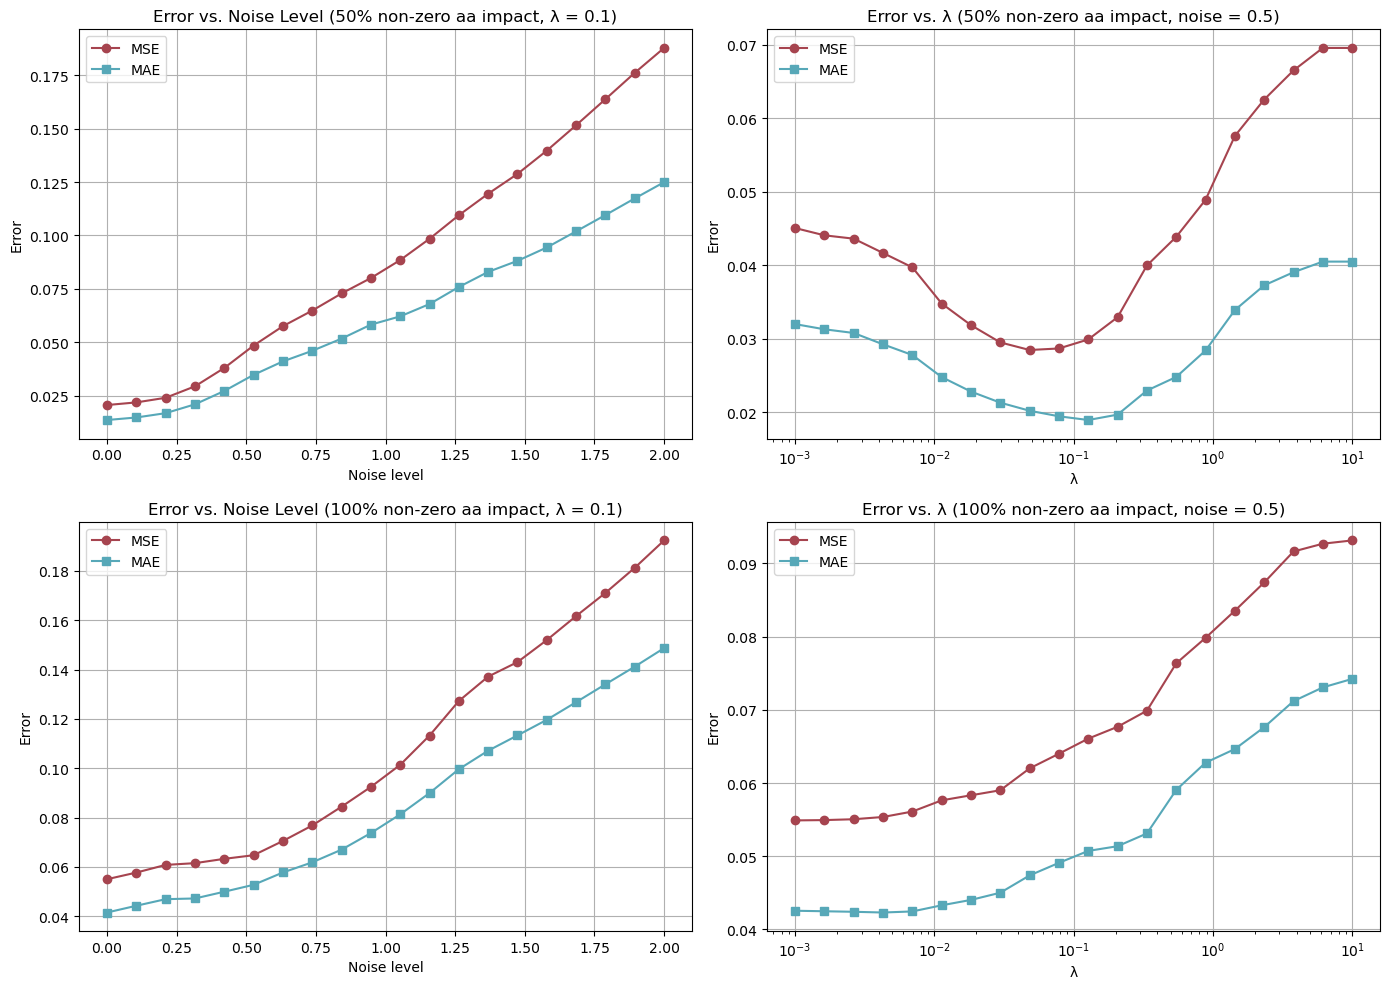

In [6]:
def sweep_metric_over_param(param_values, param_name, n_variants, n_aachanges, percent_non0impact_aa, fixed_lambda=None, fixed_noise=None):
    mses, maes = [], []

    for val in param_values:
        # Set either lambda or noise depending on the sweep
        noise_level = val if param_name == "noise" else fixed_noise
        _lambda = val if param_name == "lambda" else fixed_lambda

        data = simulate_aa_substitution_data(n_variants, n_aachanges, percent_non0impact_aa, noise_level)
        a_est = estimate_aa_impact(data['delta_s'], data['C'], data['W'], _lambda=_lambda)['a_est']

        mses.append(calculate_root_mse(a_est, data['true_a']))
        maes.append(calculate_mae(a_est, data['true_a']))

    return mses, maes

# --- Plot helper ---
def plot_error_curves(ax, x, mse, mae, title, xlabel, xscale='linear'):
    ax.plot(x, mse, marker='o', label='MSE', color= "#a6444f")
    ax.plot(x, mae, marker='s', label='MAE', color = "#57a8b8")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Error')
    ax.set_xscale(xscale)
    ax.legend()
    ax.grid(True)

# --- Experiment config ---
n_variants = 50
n_aachanges = 60
lambda_fixed = 0.05
noise_fixed = 0.3
noise_levels = np.linspace(0.0, 2.0, 20)
lambda_values = np.logspace(-3, 1, 20)

# --- Run sweeps ---
mses_noise_50, maes_noise_50 = sweep_metric_over_param(noise_levels, "noise", n_variants, n_aachanges, 0.5, fixed_lambda=lambda_fixed)
mses_lambda_50, maes_lambda_50 = sweep_metric_over_param(lambda_values, "lambda", n_variants, n_aachanges, 0.5, fixed_noise=noise_fixed)
mses_noise_100, maes_noise_100 = sweep_metric_over_param(noise_levels, "noise", n_variants, n_aachanges, 1.0, fixed_lambda=lambda_fixed)
mses_lambda_100, maes_lambda_100 = sweep_metric_over_param(lambda_values, "lambda", n_variants, n_aachanges, 1.0, fixed_noise=noise_fixed)

# --- Plot all ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_error_curves(axes[0, 0], noise_levels, mses_noise_50, maes_noise_50,
                  "Error vs. Noise Level (50% non-zero aa impact, λ = 0.1)", "Noise level")
plot_error_curves(axes[0, 1], lambda_values, mses_lambda_50, maes_lambda_50,
                  "Error vs. λ (50% non-zero aa impact, noise = 0.5)", "λ", xscale='log')
plot_error_curves(axes[1, 0], noise_levels, mses_noise_100, maes_noise_100,
                  "Error vs. Noise Level (100% non-zero aa impact, λ = 0.1)", "Noise level")
plot_error_curves(axes[1, 1], lambda_values, mses_lambda_100, maes_lambda_100,
                  "Error vs. λ (100% non-zero aa impact, noise = 0.5)", "λ", xscale='log')

plt.tight_layout()
plt.show()

Playing around with the toy example, lambda seems to effect the result in a way, that mutation which doesn't have a value get growth rates closer to 0 with smaller errors on these but also non-zero effect aa substitutions get value further off from the truth. Approximately uniform accuracy over all substitutions is reached with lambda = 0.

Quite accurate results are gained when there is no noise in the data. However adding noise significantly worsens the result.

## Covid Data USA

In [7]:
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)
consensus_seq_df

,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
lineage,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
unaliased,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
parent,,A,A,A.2,A.2,A.2,A.2,A.2.5,A.2.5,A.2.5,...,,,,,,,,,,
children,"[A.1, A.2, A.3, A.4, A.5, A.6, A.7, A.9, A.11,...",[],"[A.2.2, A.2.3, A.2.4, A.2.5]",[],[],[],"[A.2.5.1, A.2.5.2, A.2.5.3]",[],[],[],...,[],[],[],[],[],[],[],[],[],[]
nextstrainClade,19B,19B,19B,19B,19B,19B,19B,19B,19B,19B,...,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant
nucSubstitutions,"[A1T, C8782T, T28144C]","[A1T, C8782T, C17747T, A17858G, C18060T, T28144C]","[A1T, C8782T, T9477A, C14805T, G25979T, T28144...","[A1T, C4540T, C8782T, T9477A, C14805T, G25979T...","[A1T, C4540T, C8782T, T9477A, C14805T, C25714T...","[A1T, C8782T, T9477A, C12815T, C14805T, G25979...","[A1T, C275T, C1567T, C4543T, A5234G, A5488G, C...","[A1T, C275T, C1567T, C1722T, C4543T, A5234G, A...","[A1T, C275T, C1567T, C4543T, A5234G, A5488G, C...","[A1T, C275T, C1567T, G2272A, C4543T, A5234G, A...",...,"[C241T, C2470T, A2832G, C3037T, T5386G, G8393A...","[C21T, C241T, C2470T, A2832G, C3037T, C9344T, ...","[C21T, C241T, C2470T, A2832G, C3037T, C4893T, ...","[G210T, C241T, C3037T, G4181T, C5365T, C6196T,...","[C241T, T670G, C2790T, C3037T, G4184A, C4321T,...","[C241T, A2832G, C3037T, T5386G, G5924A, C9344T...","[C241T, A2832G, C3037T, C3583T, T5386G, G8393A...","[C241T, C2470T, A2832G, C3037T, G4184A, C4321T...","[C21T, C241T, A1585G, C2470T, A2832G, C3037T, ...","[C241T, T670G, C2790T, C3037T, G4184A, C4321T,..."
aaSubstitutions,[ORF8:L84S],"[ORF1b:P1427L, ORF1b:Y1464C, ORF8:L84S]","[N:S197L, ORF1a:F3071Y, ORF3a:G196V, ORF8:L84S]","[N:P13L, N:S197L, ORF1a:F3071Y, ORF3a:G196V, O...","[N:S197L, ORF1a:F3071Y, ORF3a:L108F, ORF3a:G19...","[N:S197L, ORF1a:F3071Y, ORF3a:G196V, ORF8:L84S]","[N:S197L, N:M234I, N:P383L, ORF1a:L4F, ORF1a:K...","[N:S197L, N:M234I, N:P365S, N:P383L, ORF1a:L4F...","[N:S197L, N:M234I, N:P383L, ORF1a:L4F, ORF1a:K...","[N:S197L, N:M234I, N:P383L, ORF1a:L4F, ORF1a:K...",...,"[E:T9I, M:D3G, M:Q19E, M:A63T, M:L120I, N:P13L...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:D3G, M:Q19E, M:A63T, N:P13L, N:R203K...","[E:T9I, M:D3G, M:Q19E, M:A63T, N:P13L, N:R203K...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:Q19E, M:A63T, N:P13L, N:R203K, N:G20...","[E:T9I, M:D3G, M:Q19E, M:A63T, N:P13L, N:R203K..."
nucDeletions,[],[],[],[],[],[],[21983-21991],[21983-21991],[21983-21991],[21983-21991],...,"[6513-6515, 11285-11293, 21765-21770, 21987-21...","[11288-11296, 21633-21641, 28362-28370, 29734-...","[11288-11296, 21633-21641, 28362-28370, 29734-...","[11285-11293, 21765-21770, 21987-21995, 28362-...","[11288-11296, 21633-21641, 28362-28370]","[6513-6515, 11288-11296, 21633-21641, 28362-28...","[6513-6515, 11285-11293, 28362-28370]","[11288-11296, 21633-21641, 28362-28370, 29734-...","[6513-6515, 11285-11293, 21633-21641, 28362-28...","[11288-11296, 21633-21641, 28362-28370]"
aaDeletions,[],[],[],[],[],[],"[S:L141-, S:G142-, S:V143-]","[S:L141-, S:G142-, S:V143-]","[S:L141-, S:G142-, S:V143-]","[S:L141-, S:G142-, S:V143-]",...,"[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:L...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:L3674-, ORF1a:S...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:S...","[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:L...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G...","[N:E31-, N:R32-, N:S33-, ORF1a:S2083-, ORF1a:L...","[N:E31-, N:R32-, N:S33-, ORF1a:S3675-, ORF1a:G

In [8]:
# work with aaSubstitutionsNew

substitutions_df = create_substitutions_df(consensus_seq_df)
substitutions_df


,E:A41V,E:D72G,E:E8D,E:F20L,E:F23V,E:F26L,E:L18I,E:L21F,E:L51I,E:L73F,...,S:Y248S,S:Y265C,S:Y266H,S:Y269N,S:Y28H,S:Y449H,S:Y449N,S:Y451H,S:Y453F,S:Y505H
A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XU,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XV,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XW,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [9]:
pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')

lineage_info_df = create_pango_lineage_information_df(pango_clade_mapping, consensus_seq_df)
lineage_info_df

,lineage,clade,pango_growth,clade_growth,pango_lif,clade_lif,pango_time,clade_time,parent,parent_growth_advantage
0,A.5,19B,0.000000,0.000000,0.000000,0.000000,45.181818,150.199306,A,-0.104699
1,A.1,19B,0.061626,0.000000,2.655418,0.000000,59.252306,150.199306,A,-0.043073
2,A.3,19B,0.069903,0.000000,1.155658,0.000000,63.350183,150.199306,A,-0.034796
3,A.2,19B,0.096689,0.000000,-3.888758,0.000000,107.638889,150.199306,A,-0.008009
5,A.19,19B,0.113630,0.000000,-10.290943,0.000000,246.000000,150.199306,A,0.008932
...,...,...,...,...,...,...,...,...,...,...
2985,NY.1,25A,1.085404,0.711105,-990.380803,-660.436942,1843.843750,1837.413845,LP.8.1.1,-0.002543
2986,NY.3,25A,1.085721,0.711105,-989.395070,-660.436942,1844.103896,1837.413845,LP.8.1.1,-0.002225
2987,LP.8.1.1,25A,1.087947,0.711105,-990.545404,-660.436942,1845.879013,1837.413845,LP.8.1,0.018683
2988,NW.1,25A,1.098315,0.711105,-1013.497309,-660.436942,1853.132353,1837.413845,LP.8.1.2,0.035350


- Only variants that have been sequenced at least once (in the US) are considered in the growth rate estimation, this looses 197 from the pango-clade-mapping dataframe
- only pango lineages are kept that are part of the pango clade mapping dataframe, this looses 118 lineages
- also consensus_seq_df contains more variants than included in the growth rate estimation (1378) and 3 can't be looked up.

For now, I'll include only pango lineages, that are present in all three dataframes and whoose parents have a growth rate estimate


#### Calculate covariance matrix

$$
d_i = s_c^{(i)} - s_p^{(i)} = (D \cdot s)_i
$$

$$
Cov(d) = Cov (D \cdot s) = D \cdot Cov(s) \cdot D^T
$$

In [10]:
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)

C = calculate_fitness_advantage_covariance(hess_inv, lineage_names, lineage_info_df)
np.diag(C)

array([3.95202938e-04, 1.11252770e-06, 1.64279945e-06, ...,
       8.71148404e-07, 3.03069139e-05, 7.01380544e-05], shape=(2940,))

## Estimate Amino Acid Substitution Impact

In [11]:
pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)



aa_impact = calculate_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.05, calc_max_lambda_loss=True)
aa_impact_diag_C = calculate_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.05, diag_covariance=True)

(2940, 4231)
Status: optimal
Optimal value of objective function: 19.847230871186746
Max lambda loss: 639.3564543704088
(2940, 4231)
Status: optimal
Optimal value of objective function: 19.864409029235503


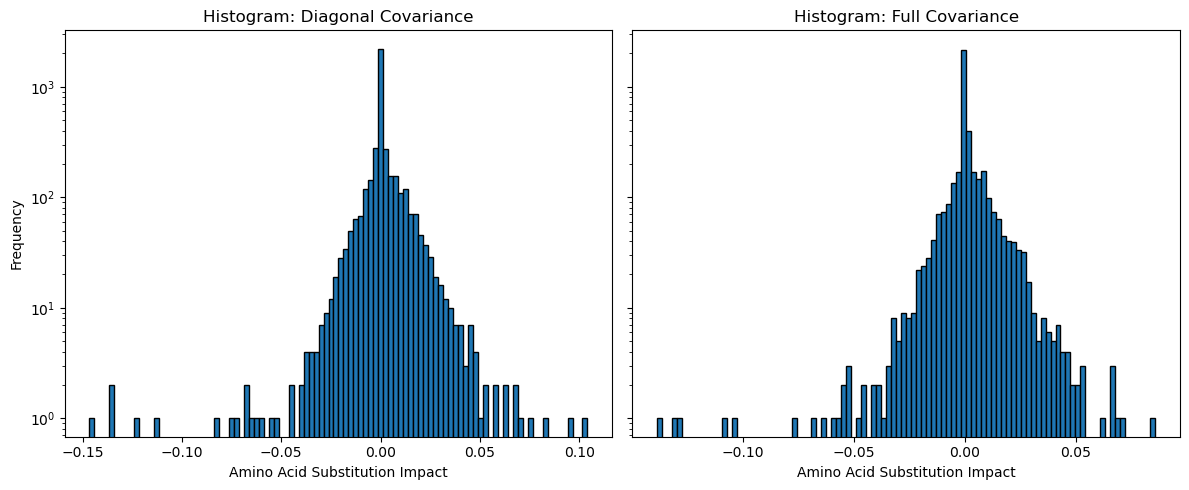

In [12]:
plot_aa_impact_dist_cov(aa_impact['a_est'], aa_impact_diag_C['a_est'])

### Choose suitable lambda parameter

In [13]:
# List of lambda values to test
lambda_values = [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01,0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

# Dictionary to store impacts for each lambda
aa_impact_C_dict = {}

# Run estimate_aa_impact for each lambda
for lam in lambda_values:
    aa_impact_C = calculate_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=lam)
    aa_impact_C_dict[lam] = aa_impact_C

(2940, 4231)
Status: optimal
Optimal value of objective function: 18.634095178663287
(2940, 4231)
Status: optimal
Optimal value of objective function: 18.635212019898002
(2940, 4231)
Status: optimal
Optimal value of objective function: 18.636620776005937
(2940, 4231)
Status: optimal
Optimal value of objective function: 18.647912982183467
(2940, 4231)
Status: optimal
Optimal value of objective function: 18.661916323423654
(2940, 4231)
Status: optimal
Optimal value of objective function: 18.771608815957453
(2940, 4231)
Status: optimal
Optimal value of objective function: 18.903874124705897
(2940, 4231)
Status: optimal
Optimal value of objective function: 19.847230871186746
(2940, 4231)
Status: optimal
Optimal value of objective function: 20.857287137310763
(2940, 4231)
Status: optimal
Optimal value of objective function: 26.532642221944833
(2940, 4231)
Status: optimal
Optimal value of objective function: 31.579370724959766
(2940, 4231)
Status: optimal
Optimal value of objective function:

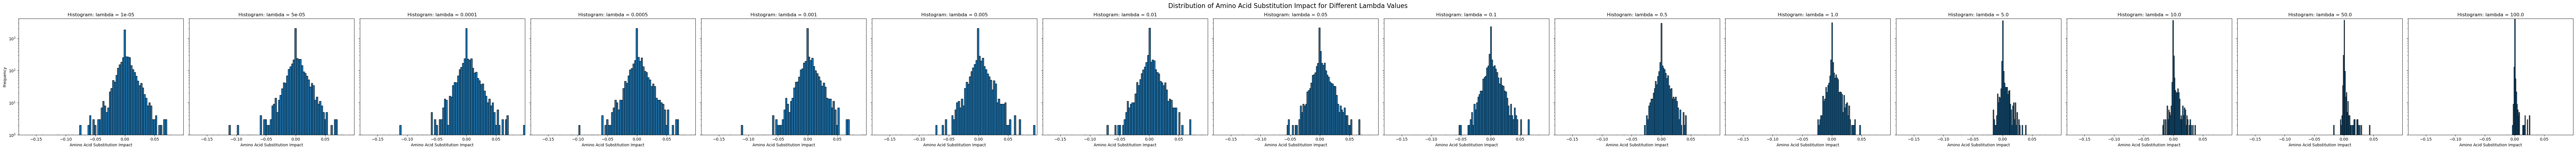

In [14]:
plot_aa_impac_distr_lambdas(lambda_values, aa_impact_C_dict)


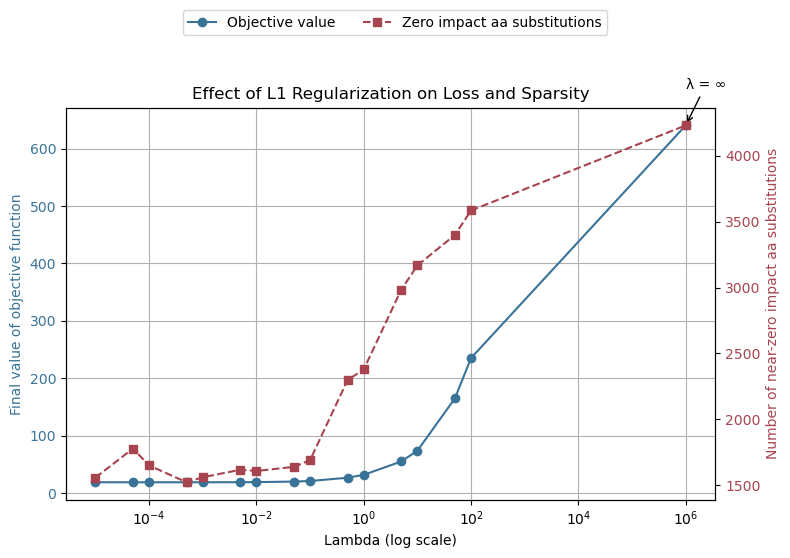

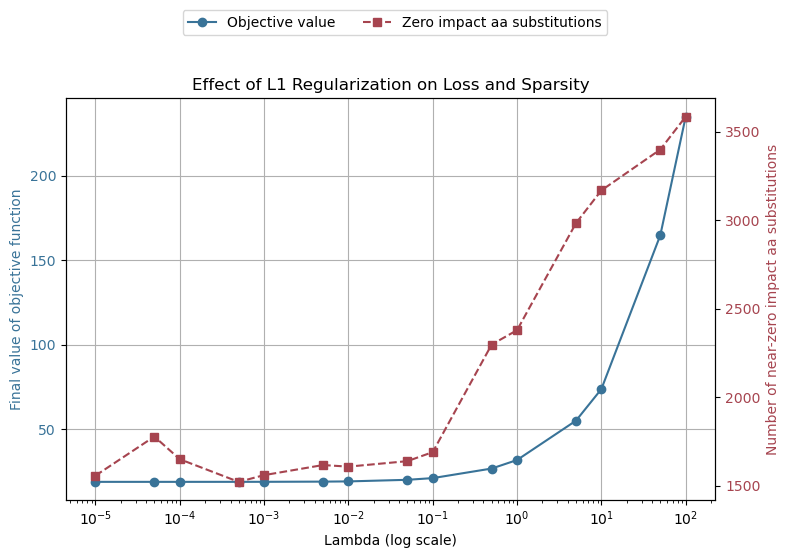

In [51]:
objective_vals = [imp['objective_value'] for imp in aa_impact_C_dict.values()]
n_zero_aa_impact = [(np.abs(imp['a_est']) < 0.0001).sum() for imp in aa_impact_C_dict.values()]
n_aa_subst = aa_impact_C_dict[1]['a_est'].shape[0]

plot_loss_different_lambda(objective_vals, n_zero_aa_impact, lambda_values, n_aa_subst, add_inf_lambda=True)
plot_loss_different_lambda(objective_vals, n_zero_aa_impact, lambda_values, n_aa_subst, add_inf_lambda=False)

Amin acid substitutions of which we know they have impact on fitness
- S:A435S (https://github.com/MurrellGroup/lineages) estimated by Murrell Group as well
- S:F486P XBB.1.5 defining
- S:G142D https://pubmed.ncbi.nlm.nih.gov/33220921/

In [16]:
def get_most_impactful_substitutions(aa_impact_vec, n, substitutions_df, lineage_info_df, abundancy_threshold = 10):
    aa_impact_df = pd.DataFrame({'aa_substitution': substitutions_df.columns, 'gr_impact': aa_impact_vec, "n_events": substitutions_df.loc[lineage_info_df.lineage.values].sum(axis = 0)})
    aa_impact_df = aa_impact_df[aa_impact_df.n_events > abundancy_threshold]
    return aa_impact_df.sort_values(by='gr_impact', ascending=False).head(n)

In [17]:
aa_impact_df_1 = get_most_impactful_substitutions(aa_impact_C_dict[1.0]['a_est'], 20, substitutions_df, lineage_info_df)
aa_impact_df_1

,aa_substitution,gr_impact,n_events
S:F486P,S:F486P,0.046934,32
S:N460K,S:N460K,0.036508,23
S:N450D,S:N450D,0.029613,24
S:A435S,S:A435S,0.029421,14
S:F456L,S:F456L,0.027705,77
ORF9b:I5T,ORF9b:I5T,0.027360,11
S:R346T,S:R346T,0.026419,117
S:L455F,S:L455F,0.025179,29
S:R403K,S:R403K,0.024859,12
S:V445P,S:V445P,0.024439,20


In [18]:
aa_impact_df_1 = get_most_impactful_substitutions(aa_impact_C_dict[0.01]['a_est'], 20, substitutions_df, lineage_info_df)
aa_impact_df_1

,aa_substitution,gr_impact,n_events
S:F486P,S:F486P,0.052940,32
S:A435S,S:A435S,0.037495,14
S:N460K,S:N460K,0.037303,23
ORF9b:I5T,ORF9b:I5T,0.034323,11
S:T22N,S:T22N,0.030093,23
S:G446S,S:G446S,0.029849,12
S:F456L,S:F456L,0.029757,77
S:N450D,S:N450D,0.029092,24
S:R346T,S:R346T,0.026570,117
S:L455F,S:L455F,0.025572,29


## Evaluate accuracy of results
Use bootstrapping to see how often an amino acid is chosen in the top 20 amino acids. Chosse $ \lambda = 0.1$

In [19]:
pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)

bootstrap_results_df, bootstrap_array = bootstrap_aa_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.05, n_runs=30, diag_covariance=False)

Min eigenvalue: (-2.9023982252748943e-19+0j)
Status: optimal
Optimal value of objective function: 8.31091535130531
Bootstrap run 1:
8.31091535130531
Min eigenvalue: (-1.9764549415658111e-19+0j)
Status: optimal
Optimal value of objective function: 12.885573684830835
Bootstrap run 2:
12.885573684830835
Min eigenvalue: (-1.2173500700387357e-19-6.169397431590868e-20j)
Status: optimal
Optimal value of objective function: 6.897679678431212
Bootstrap run 3:
6.897679678431212
Min eigenvalue: (-2.7085357597466185e-19+0j)
Status: optimal
Optimal value of objective function: 11.43359133956673
Bootstrap run 4:
11.43359133956673
Min eigenvalue: (-3.8882690383023515e-19+0j)
Status: optimal
Optimal value of objective function: 13.36196830234503
Bootstrap run 5:
13.36196830234503
Min eigenvalue: (-5.497417382548279e-19+0j)
Status: optimal
Optimal value of objective function: 9.45754815328699
Bootstrap run 6:
9.45754815328699
Min eigenvalue: (-3.9294813921697955e-19+0j)
Status: optimal
Optimal value of

In [20]:
bootstrap_results_df[bootstrap_results_df.n_events > 10].head(20)


,mean,std,ci_lower,ci_upper,aa_substitution,n_events
0,0.058893,0.006264,0.048440,0.074409,S:F486P,32
4,0.041723,0.006512,0.027834,0.053071,S:A435S,14
9,0.034730,0.005658,0.024923,0.045992,S:N460K,23
15,0.032772,0.004900,0.027065,0.042600,S:F456L,77
18,0.030498,0.005651,0.021469,0.042177,S:N450D,24
21,0.029319,0.006888,0.013630,0.042302,S:T22N,23
30,0.027176,0.002761,0.020750,0.031960,S:R346T,117
33,0.026027,0.001364,0.023712,0.028829,S:L455F,29
41,0.024394,0.009179,0.018086,0.045195,S:L452R,27
42,0.024153,0.004314,0.018738,0.032740,S:V445P,20


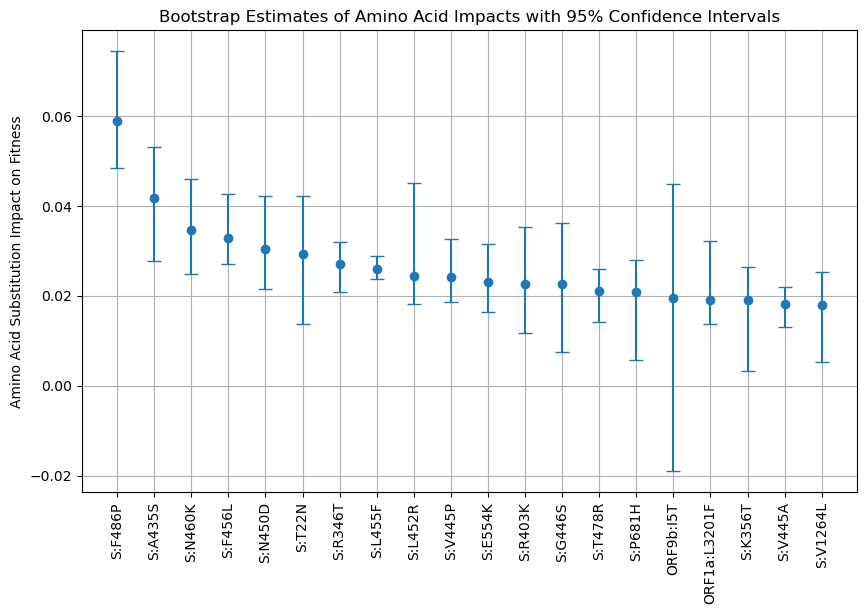

In [21]:
plot_bootstrap_aa_impact(bootstrap_results_df, 20, abundancy_threshold=10)

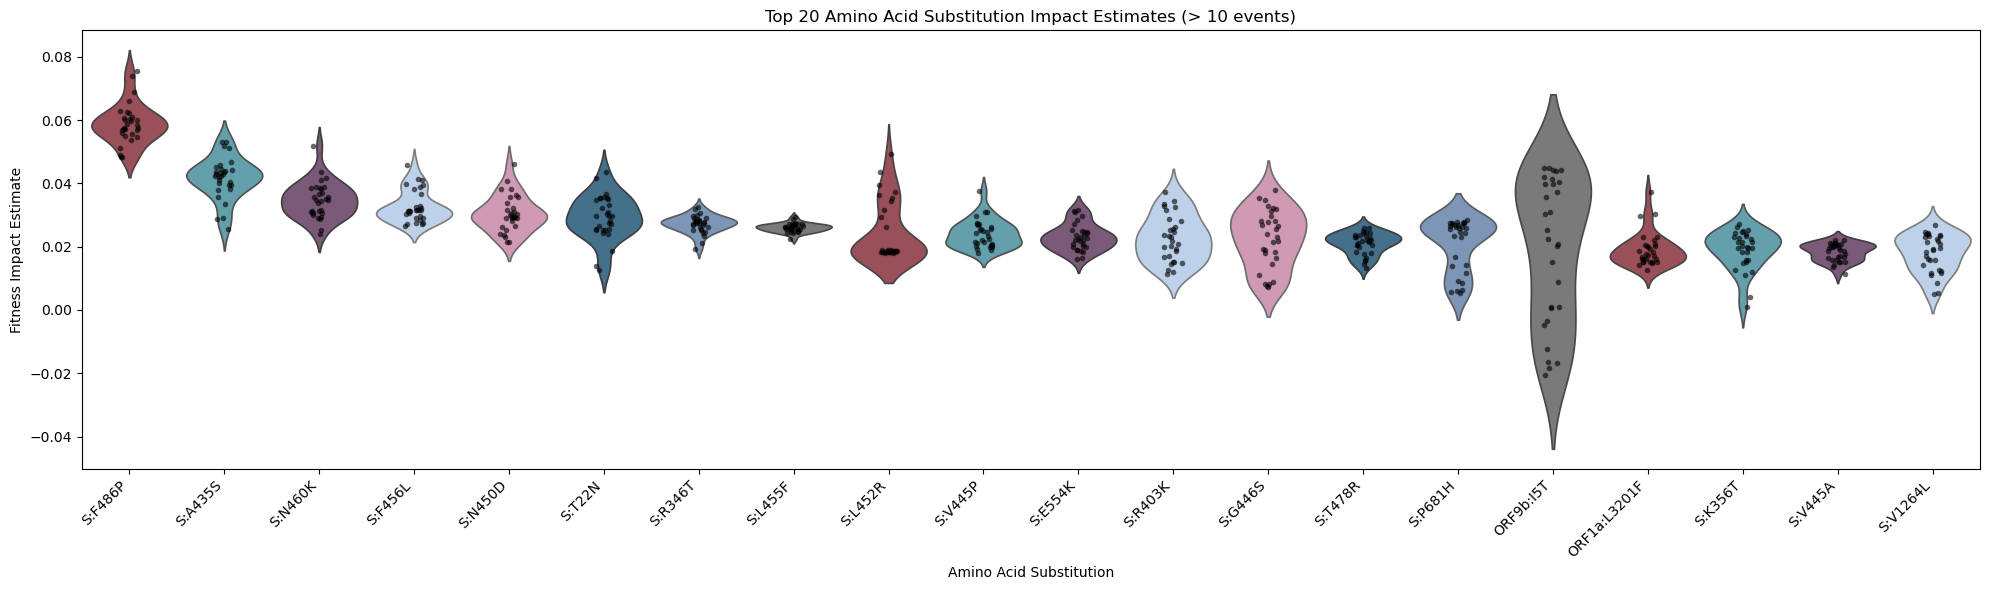

In [22]:
plot_bootstrap_aa_impact_violin(bootstrap_results_df, bootstrap_array, 20, abundancy_threshold=10)


### Consider amino acid substitutions impact over time

As a next step, we want to see if the impact of amino acid substitutions changes over time. To do this, we split the known amino acid clades into 4 time intervals:
- alpha to delta variants: A.1 to AY..., clades: 19B to 21J, around January 2020 to December 2021
- omicron: BA.1 ..., clades: 21K to 23C, aroung January 2022 to December 2022
- omicron XBB: XBB.1 ... , clades: 23A to 23H, around January 2023 to November 2023
- JN1: clades: 23I to 24A, December 2023 to April 2025

In [23]:
clades_1 = ['19B', '20C', '20A', '20B', '20G', '20E', '21C', '20D', '21D','21F', '20H', '21E', '21B', '20I', '19A', '20J', '21G', '21H','21A', '21I', '21J']
clades_2 = ['21K', '21M', '21L', '22C', '22A', '22B','22D', '22E', '23C']
clades_3 = ['23A', '22F', '23D', '23E', '23B', '23G', '23F', '23H']
clades_4 = ['23I', '24A']

clade_split = [clades_1, clades_2, clades_3, clades_4]

labels = ['Alpha to Delta', 'Omicron', 'XBB', 'JN']

In [24]:
pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)

aa_impact_time_df, lineages_list = calculate_impact_estimates_timesplit(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.05, clade_split=clade_split, diag_covariance=False)

Status: optimal
Optimal value of objective function: 43.7026971444551
Status: optimal
Optimal value of objective function: 12.04653145273025
Status: optimal
Optimal value of objective function: 10.157291720310742
Status: optimal
Optimal value of objective function: 9.511661459650513


In [25]:
aa_impact_time_df[aa_impact_time_df.n_events > 10].head(20)

,aa_substitution,n_events,impact_clades1,events_clades1,impact_clades2,events_clades2,impact_clades3,events_clades3,impact_clades4,events_clades4,max_impact
3529,S:F486P,32,-8.903497e-17,0,7.881133e-02,4,5.578805e-02,27,9.908384e-03,1,0.078811
3262,ORF9b:I5T,11,9.150415e-03,2,-5.550949e-17,0,4.367062e-02,8,7.032926e-16,0,0.043671
3524,S:F456L,77,-8.903497e-17,0,1.999286e-02,1,2.576590e-02,37,4.343801e-02,38,0.043438
3751,S:L452R,27,2.901756e-02,10,3.672837e-02,14,1.787456e-02,3,7.032926e-16,0,0.036728
1324,ORF1a:P1640L,43,3.635900e-02,42,-5.550949e-17,0,-8.913041e-16,0,1.446577e-02,1,0.036359
3703,S:K444N,12,-8.903497e-17,0,6.485774e-03,11,3.633878e-02,1,7.032926e-16,0,0.036339
3823,S:N460K,23,-8.903497e-17,0,3.606734e-02,22,-8.913041e-16,0,9.908384e-03,1,0.036067
3819,S:N450D,24,-8.903497e-17,0,3.508193e-02,16,2.246852e-02,7,9.908384e-03,1,0.035082
3943,S:Q677H,15,5.582762e-03,6,2.001030e-02,3,1.711654e-03,2,3.505442e-02,2,0.035054
3584,S:G446S,12,-8.903497e-17,0,3.484617e-02,11,-8.913041e-16,0,9.908384e-03,1,0.034846


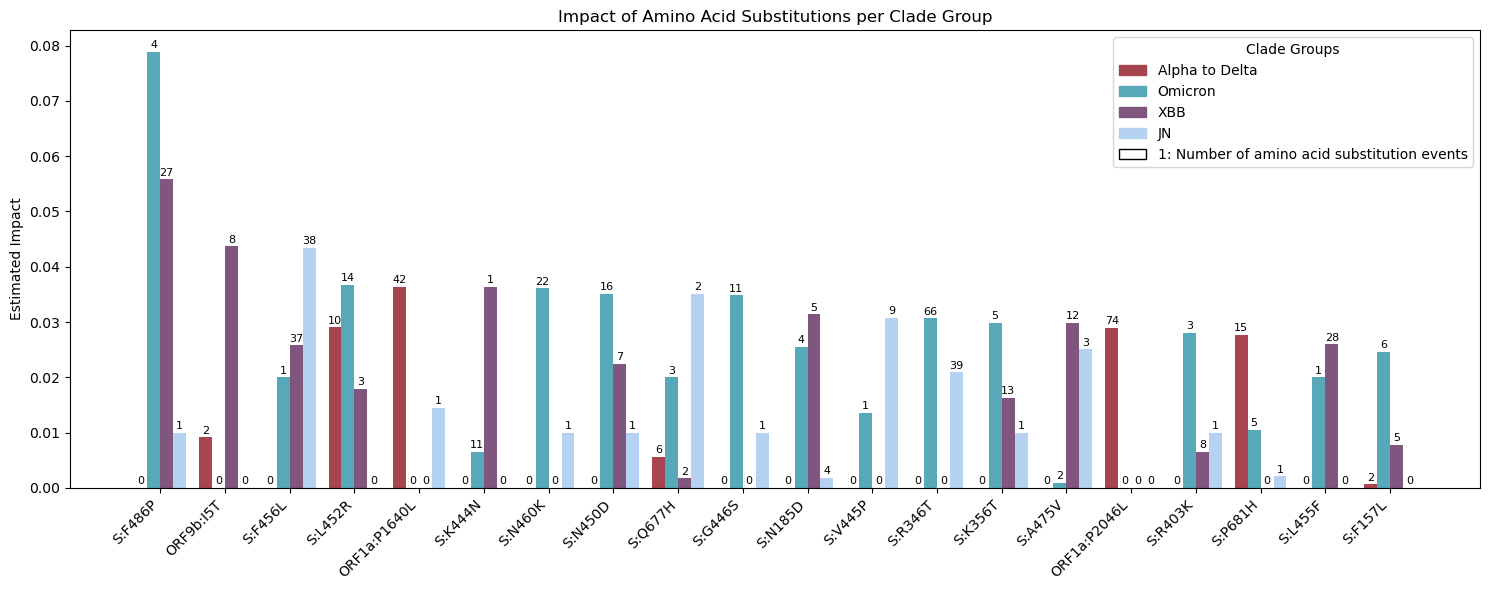

In [28]:
plot_aa_impact_time(aa_impact_time_df, labels, top_n=20, abundancy_threshold=10)
